#  Titanic Visual Deep-Dive

## Understanding Survival Patterns Through Data Visualization

### Author: Vaishali Vittal Moolya

This notebook explores the Titanic disaster through a series of publication-quality visualizations to understand which factors most influenced passenger survival.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 11

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

The Titanic dataset contains passenger demographics, ticket information, travel class, embarkation details, and survival status.

Our goal is to identify the strongest factors that influenced survival.

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 891
Columns : 12


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Data Cleaning

Before creating visualizations, missing values were handled to ensure reliable analysis. Missing age values were replaced using the median age, while missing embarkation records were filled using the most frequent embarkation port.

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

### Observation

After handling missing values, the Age and Embarked columns no longer contain null values. The Cabin column still has many missing entries, but it is not required for the visualizations performed in this analysis.

## 1. Overall Survival Distribution

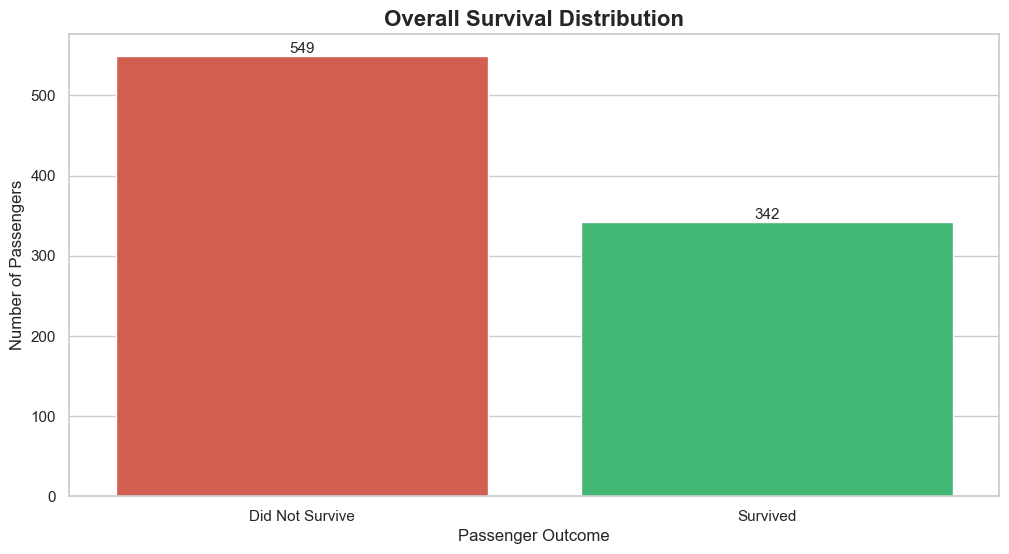

In [8]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x='Survived',
    hue='Survived',
    palette=['#E74C3C', '#2ECC71'],
    legend=False
)

plt.title(
    "Overall Survival Distribution",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Passenger Outcome")
plt.ylabel("Number of Passengers")

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Did Not Survive",
    "Survived"
])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Key Insight

More passengers perished than survived, demonstrating the scale of the Titanic tragedy.

## 2. Survival Rate by Gender

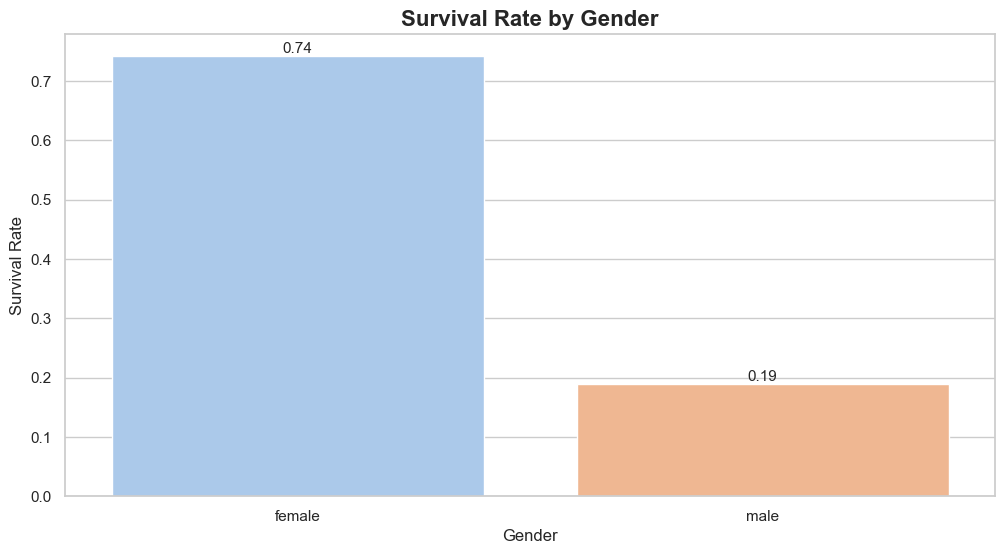

In [9]:
gender_survival = (
    df.groupby('Sex')['Survived']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=gender_survival,
    x='Sex',
    y='Survived',
    hue='Sex',
    palette='pastel',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.title(
    "Survival Rate by Gender",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

### Key Insight

Women were dramatically more likely to survive, reflecting the evacuation priority given to women and children.

## 3. Passenger Class and Survival

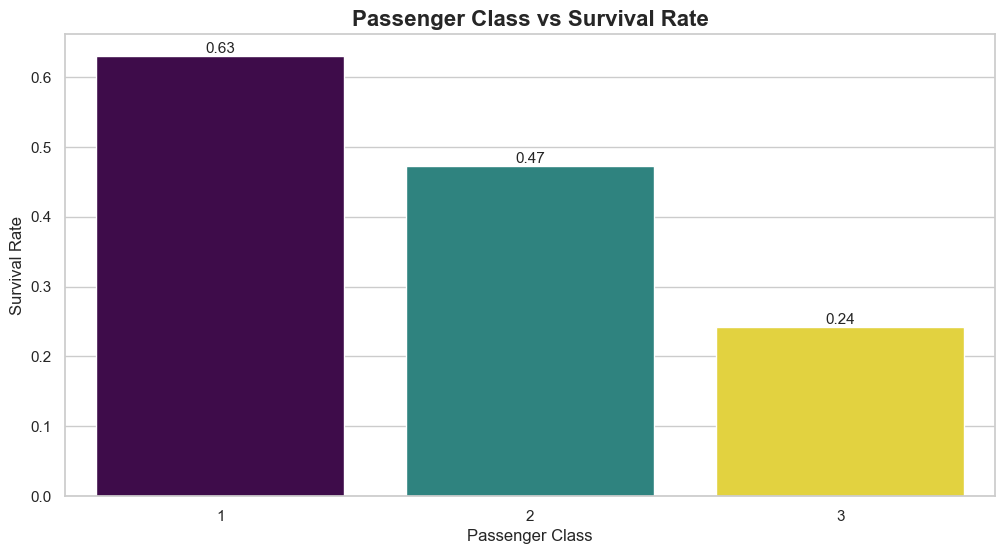

In [10]:
class_survival = (
    df.groupby('Pclass')['Survived']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=class_survival,
    x='Pclass',
    y='Survived',
    hue='Pclass',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.title(
    "Passenger Class vs Survival Rate",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Key Insight

Passengers in first class enjoyed significantly better survival outcomes than those in lower classes.

## 4. Age Distribution by Survival Status

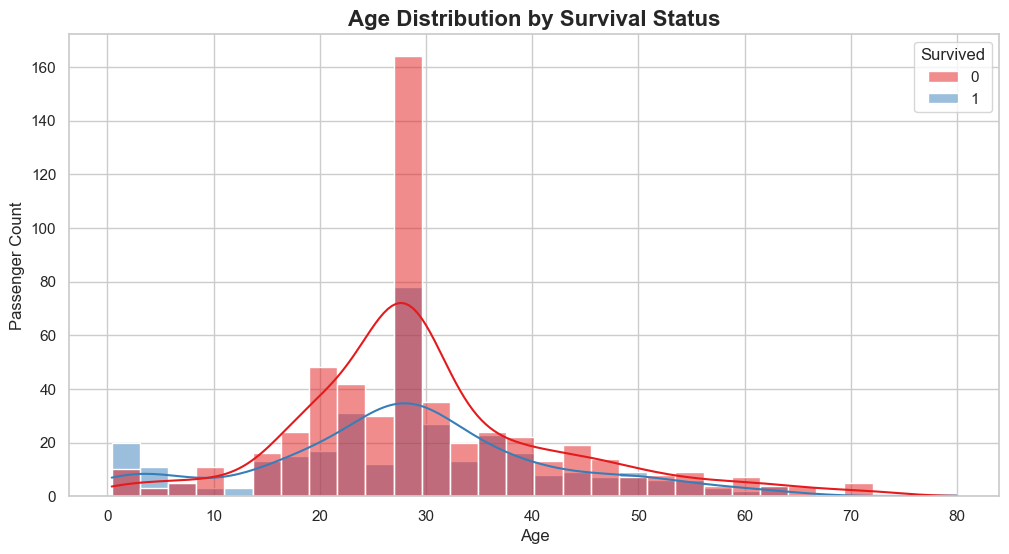

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='Age',
    hue='Survived',
    kde=True,
    bins=30,
    palette='Set1'
)

plt.title(
    "Age Distribution by Survival Status",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Age")
plt.ylabel("Passenger Count")

plt.show()

### Key Insight

Children and younger passengers generally had stronger survival prospects.

## 5. Fare Paid vs Survival

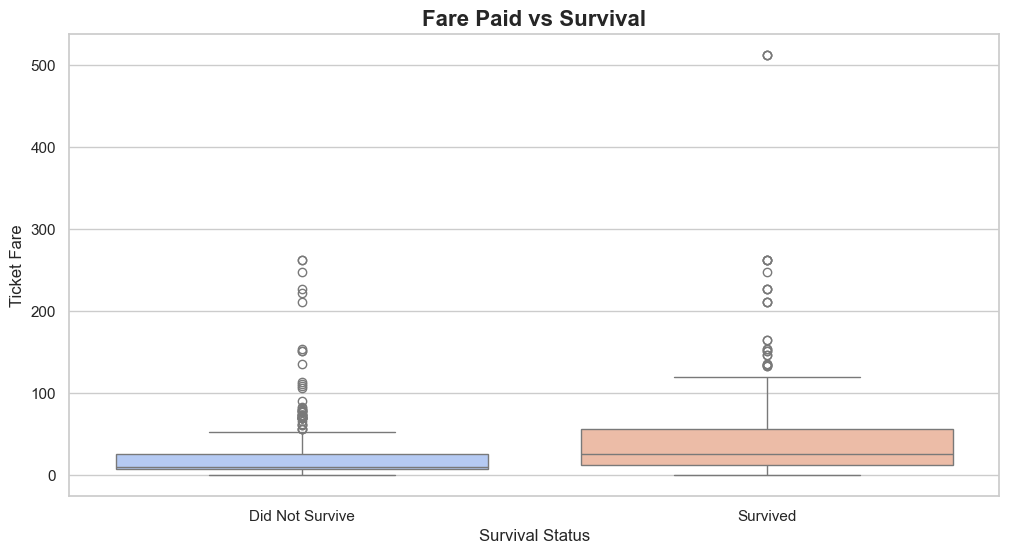

In [12]:
plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df,
    x='Survived',
    y='Fare',
    hue='Survived',
    palette='coolwarm',
    legend=False
)

plt.title(
    "Fare Paid vs Survival",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Survival Status")
plt.ylabel("Ticket Fare")

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Did Not Survive",
    "Survived"
])

plt.show()

### Key Insight

Passengers paying higher fares generally experienced higher survival rates.

## 6. Embarkation Port and Survival

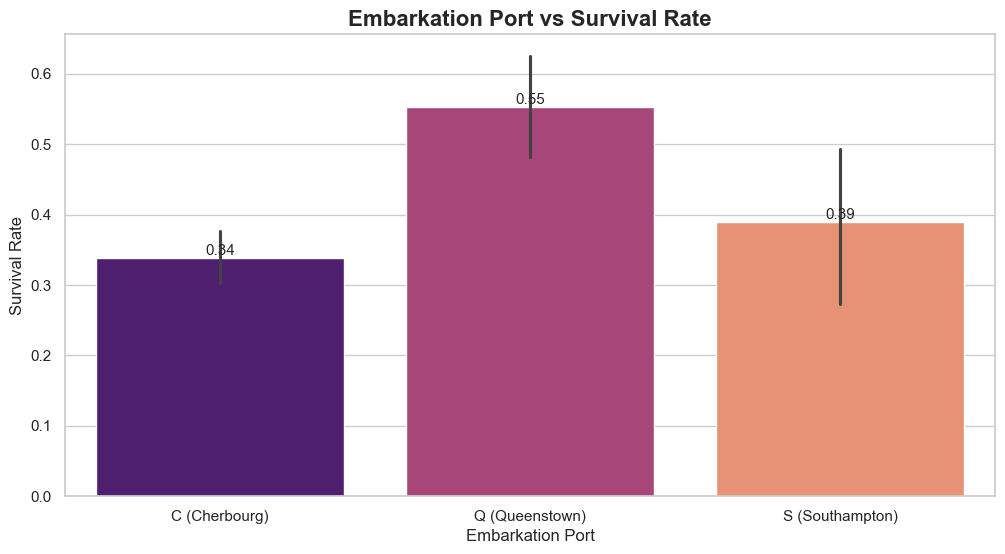

In [13]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df,
    x='Embarked',
    y='Survived',
    hue='Embarked',
    palette='magma',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.title(
    "Embarkation Port vs Survival Rate",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate")

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([
    "C (Cherbourg)",
    "Q (Queenstown)",
    "S (Southampton)"
])

plt.show()

### Key Insight

Survival rates differed across embarkation ports, suggesting differences in passenger demographics and class composition.

# Key Findings

1. Women had the highest survival probability.
2. First-class passengers enjoyed substantial advantages.
3. Younger passengers tended to survive more often.
4. Higher ticket fares correlated with higher survival.
5. Passenger location and boarding patterns influenced outcomes.
6. Survival was heavily shaped by social and economic factors.

# Conclusion

The visualizations reveal that survival aboard the Titanic was strongly influenced by demographic and socioeconomic factors. Women experienced substantially higher survival rates than men, supporting the well-known "women and children first" evacuation practice. Passenger class emerged as another major determinant, with first-class travelers enjoying a significantly greater chance of survival.

Age analysis suggests younger passengers generally fared better during the disaster. Fare distribution further indicates that wealthier passengers, represented by higher ticket prices, were more likely to survive. Differences in survival rates across embarkation ports suggest that passenger composition and travel circumstances varied by location.

Taken together, these charts demonstrate that survival was not random. Gender, social class, age, and economic status all played meaningful roles in determining passenger outcomes. Through data visualization, the Titanic dataset provides a powerful example of how social and demographic factors can influence outcomes during large-scale historical events.

## Final Takeaway

The Titanic disaster demonstrates how demographic and socioeconomic factors can strongly influence outcomes during emergencies. Through visual analytics, patterns hidden within historical data become easier to understand and communicate.